# Inference the fine-tuned Vision Transformer Model (ViT-B-16)

The model was train to detect if the person in an image is real or AI generated. See this [Script](fine_tuning_ViT_google_pretrained_more_aug.ipynb)

# 1. Import

In [33]:
import torch
import torch.nn.functional as F
import torch.nn as nn

from torchvision import models, transforms

import matplotlib.pyplot as plt
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


# 2. Connect to Google Drive

In [34]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    MODEL_PATH = '/content/drive/MyDrive/DL/FT_ViT_Fake_Real_Person.pth'
    FAKE_IMG = '/content/drive/MyDrive/DL/fake_person.png'
    FAKE_SQ_IMG = '/content/drive/MyDrive/DL/fake_person_square.png'
    REAL_IMG = '/content/drive/MyDrive/DL/zendaya.png'
    REAL_SQ_IMG = '/content/drive/MyDrive/DL/zendaya_square.png'
except(Exception) as e:
    print(f"❌ Error: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 3. Transform the Input Image

In [35]:
class LetterBox:
    def __init__(self, fill_color=(128, 128, 128)):
        self.fill_color = fill_color

    def __call__(self, img):
        w, h = img.size
        side = max(w, h) # the size of the quare canvas

        # create a neutral gray square canvas
        canvas = Image.new('RGB', (side, side), self.fill_color)

        # Paste the original image centered on the canvas
        pad_left = (side - w) // 2
        pad_top = (side - h) // 2
        canvas.paste(img, (pad_left, pad_top))

        return canvas

In [36]:
stats = ((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))

IMG_SIZE = 256

inference_transform = transforms.Compose([
    LetterBox(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

# 4. Load the pretrained Weights

In [37]:
def load_weights(model_path, device):
    # 1. Load a empty model
    model = models.vit_b_16(weights=None, image_size=IMG_SIZE)
    model.heads.head = nn.Linear(model.heads.head.in_features, 2)

    # 2. Load the weights
    state_dict = torch.load(model_path, map_location=device)

    # 3. Move the weights into the model
    model.load_state_dict(state_dict)

    # 4. Set to eval mode (disables dropout, batch norm)
    model.eval()
    model.to(device)

    print("✅ Model loaded")
    return model

model = load_weights(MODEL_PATH, device);

✅ Model loaded


# 5. Predict Function

In [38]:
def predict(img_path, model, transform, classes=["fake", "real"]):
    print("Inference running ...")
    # 1. Load the Image
    img = Image.open(img_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)

    # 2. Inference
    with torch.no_grad():
        output = model(input_tensor)
        probs = F.softmax(output, dim=1)
        conf, pred = torch.max(probs, 1)

    class_name = classes[pred.item()]
    confidence = conf.item() * 100

    return class_name, confidence, img

# 6. Inference and Visualization with GradCAM

In [39]:
fake_cls, fake_score, fake_img = predict(FAKE_IMG, model, inference_transform)
fake_sq_cls, fake_sq_score, fake_sq_img = predict(FAKE_SQ_IMG, model, inference_transform)

real_cls, real_score, real_img = predict(REAL_IMG, model, inference_transform)
real_sq_cls, real_sq_score, rea_sq_img = predict(REAL_SQ_IMG, model, inference_transform)

Inference running ...
Inference running ...
Inference running ...
Inference running ...


In [40]:
!pip install grad-cam -q

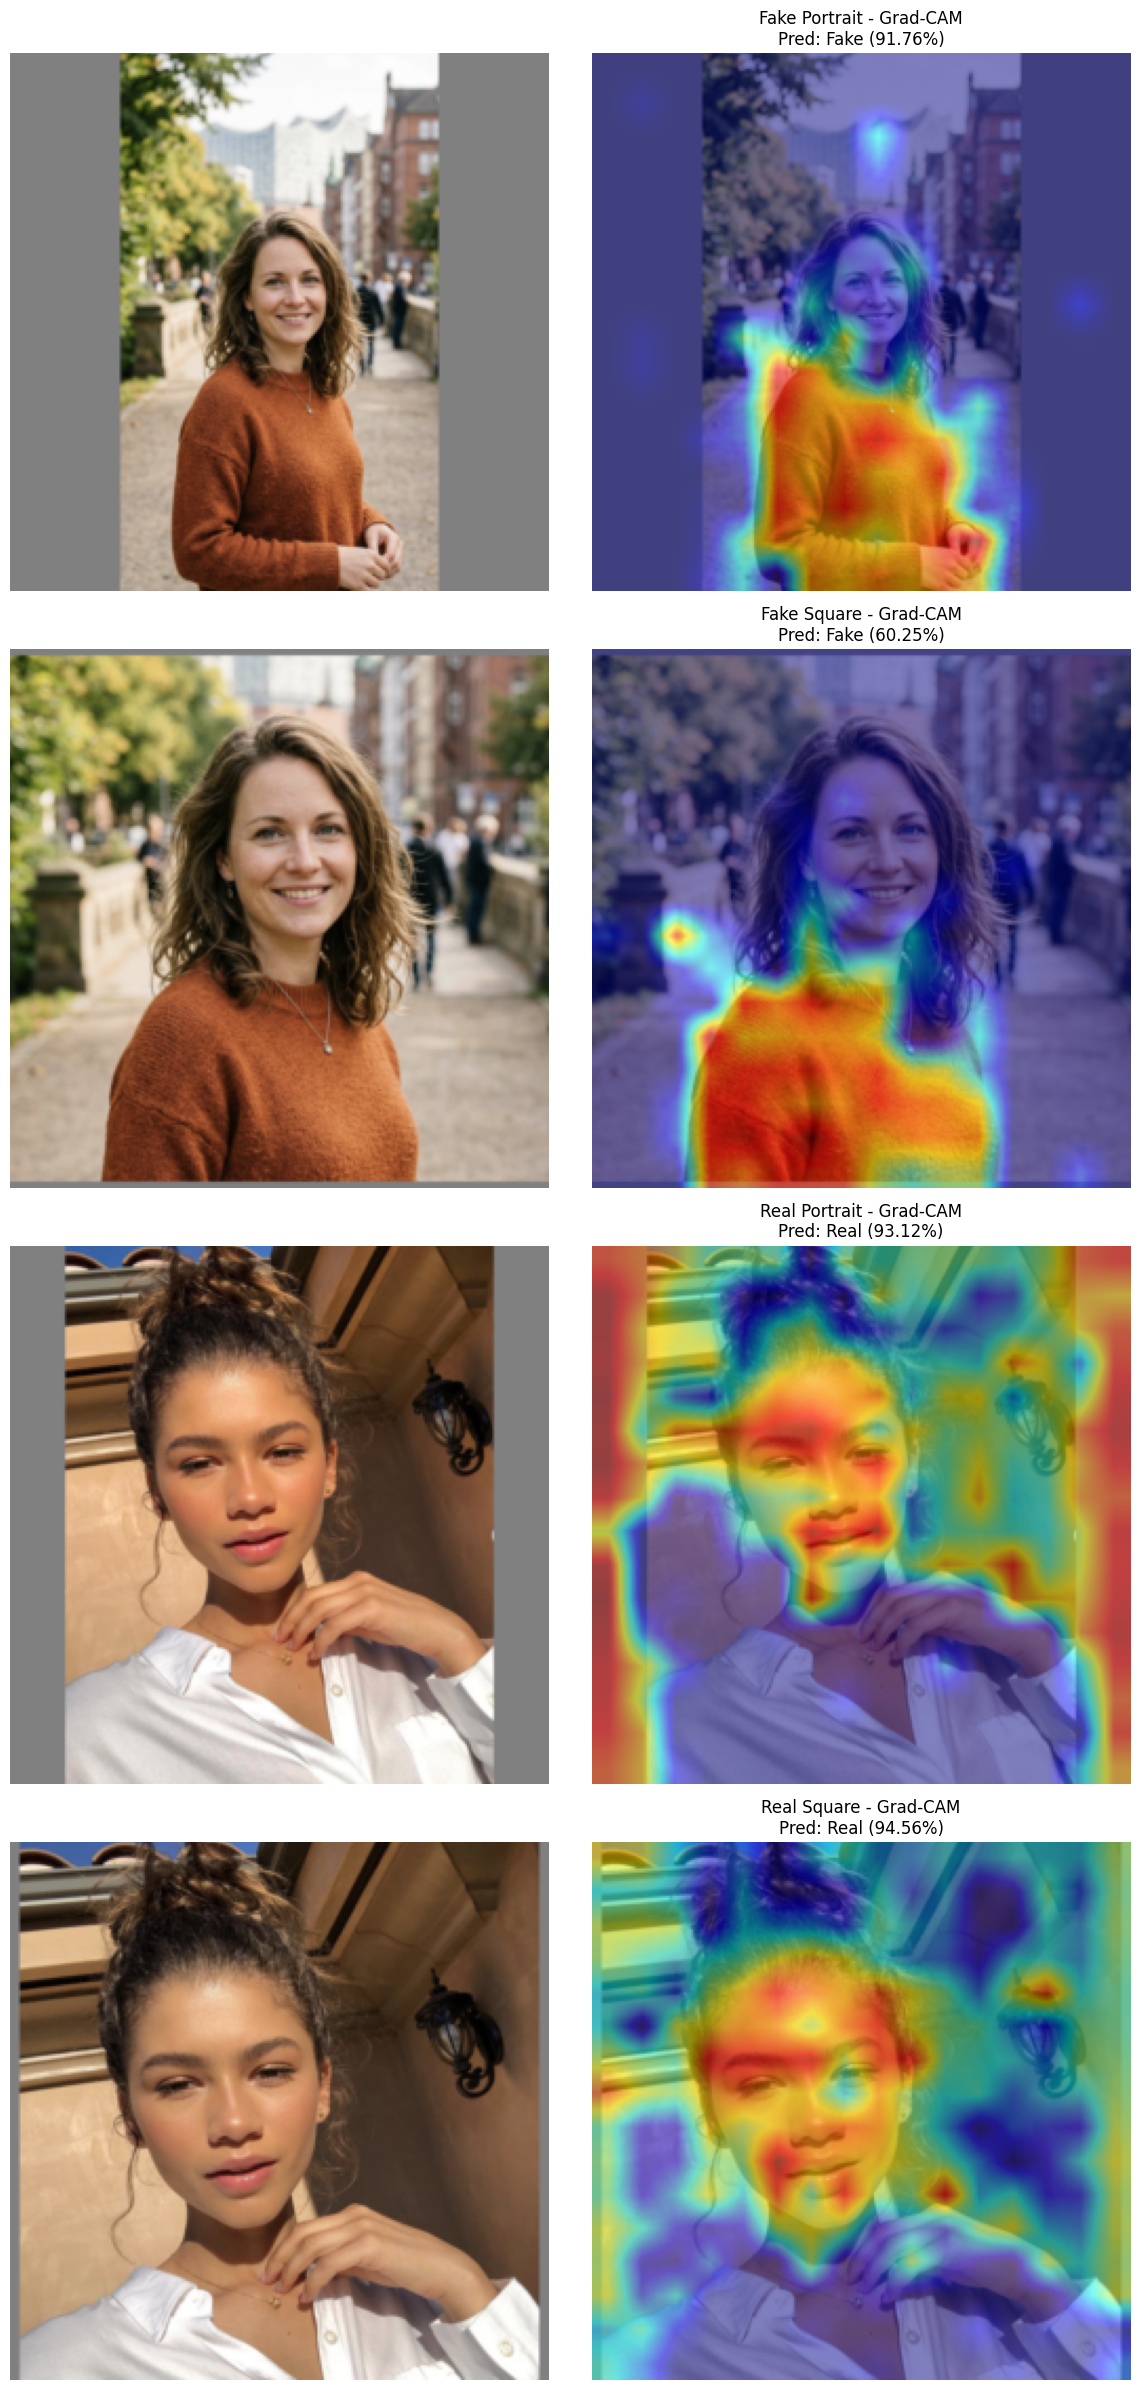

In [41]:
import numpy as np
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# 1. Reshaping function for ViT
def reshape_transform(tensor, height=16, width=16):
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.transpose(2, 3).transpose(1, 2)
    return result

# 2. Re-normalization function (to display heatmap on original image)
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

# 3. Setup the GradCAM
target_layers = [model.encoder.layers[-1].ln_1]
cam = GradCAM(model=model, target_layers=target_layers, reshape_transform=reshape_transform)

def generate_heatmap(img_path, model, cam, transform):
    # 1. Load and Transform Image
    img = Image.open(img_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)
    
    # 2. Generate Heatmap
    grayscale_cam = cam(input_tensor=input_tensor)[0, :]
    
    # 3. Format Original Image (Reverse Normalization)
    # We use the transformed tensor and invert it to get the exact pixels the model saw
    orig_image = inv_normalize(input_tensor[0]).cpu().permute(1, 2, 0).numpy()
    orig_image = np.clip(orig_image, 0, 1)
    
    # 4. Overlay Heatmap
    visualization = show_cam_on_image(orig_image, grayscale_cam, use_rgb=True)
    
    # 5. Prediction
    with torch.no_grad():
        output = model(input_tensor)
        pred = output.argmax(1).item()
        prob = torch.nn.functional.softmax(output, dim=1)[0, pred].item()
    
    return orig_image, visualization, pred, prob

# Generate for Fake and Real images (both Square and Portrait)
images_to_test = []
if 'FAKE_IMG' in locals(): images_to_test.append(('Fake Portrait', FAKE_IMG))
if 'FAKE_SQ_IMG' in locals(): images_to_test.append(('Fake Square', FAKE_SQ_IMG))
if 'REAL_IMG' in locals(): images_to_test.append(('Real Portrait', REAL_IMG))
if 'REAL_SQ_IMG' in locals(): images_to_test.append(('Real Square', REAL_SQ_IMG))

if len(images_to_test) > 0:
    fig, axs = plt.subplots(len(images_to_test), 2, figsize=(12, 6 * len(images_to_test)))
    if len(images_to_test) == 1:
        axs = np.expand_dims(axs, axis=0)

    for i, (label, path) in enumerate(images_to_test):
        try:
            orig, vis, pred, prob = generate_heatmap(path, model, cam, inference_transform)
            
            axs[i, 0].imshow(orig)
            axs[i, 0].axis('off')
            
            axs[i, 1].imshow(vis)
            axs[i, 1].set_title(f"{label} - Grad-CAM\nPred: {'Real' if pred == 1 else 'Fake'} ({prob*100:.2f}%)")
            axs[i, 1].axis('off')
        except Exception as e:
            print(f"❌ Error processing {path}: {e}")

    plt.tight_layout()
    plt.show()
else:
    print("No images found to test.")

# Explanation of Model Behavior

Our analysis of the Grad-CAM heatmaps reveals a significant bias in how the model classifies Real vs. Fake images:

1. **Training Data Bias**: A review of the [training set](https://www.kaggle.com/datasets/ayushmandatta1/deepdetect-2025) shows a distinct imbalance in image framing. **Fake** (AI-generated) images mostly consist of close-up shots showing only the **face and neck**, whereas **Real** images often include both the **face and body parts**.
   
2. **Unexpected Dependence on Body Parts**: Despite the training bias (where the presence of a body was originally associated with 'Real' samples), the model relies heavily on the **body part** of the fake person during inference to confirm its 'Fake' classification. 

3. **Confidence and Anomaly Detection**:
- **Confidence Jump**: The model's confidence increases drastically from **~60%** (Fake Square/Face-only) to over **91%** (Fake Portrait/Face+Body).
- **Shortcut Learning**: Since the training set lacked 'Fake Bodies,' the model treats unfamiliar textures (like the sweater) and the sharp edges created by the `LetterBox` padding as 'AI artifacts.' It is using these layout features as a shortcut rather than focusing on the actual face to determine authenticity.

3. **Bars on the Real Images:**

- **Differential Attention:** Interestingly, the model "looks" at the gray bars on the Real image but ignores them on the Fake image.

- Signal Dominance: In the Fake image, the "loudness" of the anomalous body texture (the sweater) provides enough signal for a high-confidence prediction, causing the model to ignore the neutral bars.

- Attention Spillover: For the Real image, the model finds strong local features on the face but also attempts to find meaning in the rest of the 16x16 patch grid. The perfectly uniform gray bars might mathematically suggest a "cleaner" background which the model mistakenly correlates with Real photography.

5. **Real Decision Logic:**

- For the Real image (Zendaya), the model correctly prioritizes the face (forehead and cheeks).
- This indicates that it is successfully recognizing natural skin lighting, organic gradients, and subsurface scattering—features that stay consistent in real human skin but are often slightly "off" in AI generations.


**Conclusion**: The model has become a **'Body Anomaly Detector'** rather than a 'Fake Face Detector.' It is brittle and sensitive to image framing, indicating that the training set needs more diverse samples (fake images with bodies and real images with varied backgrounds/framing) to improve true generalization.